# Escalonamento das variáveis quantitativas (Anexo A.1)

Este notebook testa a normalidade das variáveis quantitativas (seção **A.1.1**), aplica as
equações de escalonamento publicadas na seção **A.1.4** do documento e reproduz as estatísticas
que aparecem nas seções **A.1.2** e **A.1.3**. Cada seção numerada aqui corresponde a um ponto
citado no documento, para que qualquer número publicado possa ser rastreado até a célula que o
produziu.

As três variáveis tratadas são `TEMPO_VOO`, `ATRASO_CHEGADA` e `QTDE_VIAGENS_12M`.

**Base de entrada.** O notebook lê `data/processed/base_analitica.parquet`, gerado por
`notebooks/pre-processamento.ipynb`. A pasta `data/` não é versionada, por compromisso entre o
Inteli e o parceiro, então o arquivo precisa existir localmente antes da execução. Se ele não for
encontrado, o notebook reconstrói a base a partir de `data/raw` usando `scripts/preprocessamento_nps.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

CAMINHOS_BASE = [
    Path('data/processed/base_analitica.parquet'),
    Path('../data/processed/base_analitica.parquet'),
    Path('/content/data/processed/base_analitica.parquet'),
]
caminho_base = next((c for c in CAMINHOS_BASE if c.exists()), None)

if caminho_base is not None:
    df = pd.read_parquet(caminho_base)
else:
    for pasta_codigo in [Path('scripts'), Path('../scripts'), Path('/content/scripts')]:
        if pasta_codigo.exists():
            sys.path.insert(0, str(pasta_codigo.resolve()))
    from preprocessamento_nps import integrar_bases, preparar_base_analitica

    df_bruto, _ = integrar_bases('data/raw')
    df = preparar_base_analitica(df_bruto)

VARIAVEIS = ['TEMPO_VOO', 'ATRASO_CHEGADA', 'QTDE_VIAGENS_12M']

print('Registros na base analítica:', f'{len(df):,}'.replace(',', '.'))

Registros na base analítica: 484.915


## 0. Teste de normalidade das variáveis quantitativas (seção A.1.1)

Testa se `TEMPO_VOO`, `ATRASO_CHEGADA` e `QTDE_VIAGENS_12M` seguem distribuição normal, com
α = 0,05. O teste de Shapiro-Wilk não é usado porque perde confiabilidade acima de ~5.000
observações e a base tem 484.915 registros; usamos D'Agostino-Pearson (`scipy.stats.normaltest`),
que combina assimetria e curtose numa estatística qui-quadrado com 2 graus de liberdade e não
impõe esse teto.


In [2]:
from scipy import stats

resultados_normalidade = []
for coluna in VARIAVEIS:
    dados = df[coluna].dropna()
    estatistica, p_valor = stats.normaltest(dados)
    resultados_normalidade.append({
        'variavel': coluna,
        'n_valido': len(dados),
        'assimetria': round(dados.skew(), 4),
        'estatistica_dagostino': round(estatistica, 2),
        'p_valor': p_valor,
        'media': round(dados.mean(), 4),
        'mediana': round(dados.median(), 4),
    })

tabela_normalidade = pd.DataFrame(resultados_normalidade).set_index('variavel')
tabela_normalidade['conclusao'] = tabela_normalidade['p_valor'].apply(
    lambda p: 'Rejeita H0 (não normal)' if p < 0.05 else 'Não rejeita H0 (compatível com normal)'
)
tabela_normalidade['diferenca_media_mediana'] = (
    tabela_normalidade['media'] - tabela_normalidade['mediana']
).abs().round(4)

tabela_normalidade


,n_valido,assimetria,estatistica_dagostino,p_valor,media,mediana,conclusao,diferenca_media_mediana
variavel,,,,,,,,
TEMPO_VOO,484675,3.6829,393750.55,0.0,207.1565,130.0,Rejeita H0 (não normal),77.1565
ATRASO_CHEGADA,484915,10.7552,782753.10,0.0,25.6551,0.0,Rejeita H0 (não normal),25.6551
QTDE_VIAGENS_12M,484760,4.1238,423564.33,0.0,3.1690,1.0,Rejeita H0 (não normal),2.1690


### Histogramas (seção A.1.1)

Um histograma por variável, gravado em `assets/` e publicado como Figuras 7 a 9 do documento.

Três decisões de desenho, para que a figura mostre exatamente o que o texto afirma:

- **Eixo vertical em escala logarítmica.** Em escala linear, a barra dominante achata todo o
  resto contra o eixo e a cauda desaparece, tornando as três distribuições visualmente idênticas.
- **Eixo horizontal cortado no percentil 99**, com o número de registros omitidos declarado na
  própria figura. Sem o corte, o eixo se estende até valores extremos isolados e sobra vazio.
- **`ATRASO_CHEGADA` recebe uma barra própria para o valor zero.** Com intervalos uniformes, a
  primeira barra reuniria os voos pontuais e os atrasos curtos num único bloco, e não seria
  possível atribuir a ela os 79,6% de zeros. A barra isolada separa esses dois grupos.

Os eixos usam separador de milhar com ponto, conforme a norma adotada no documento.


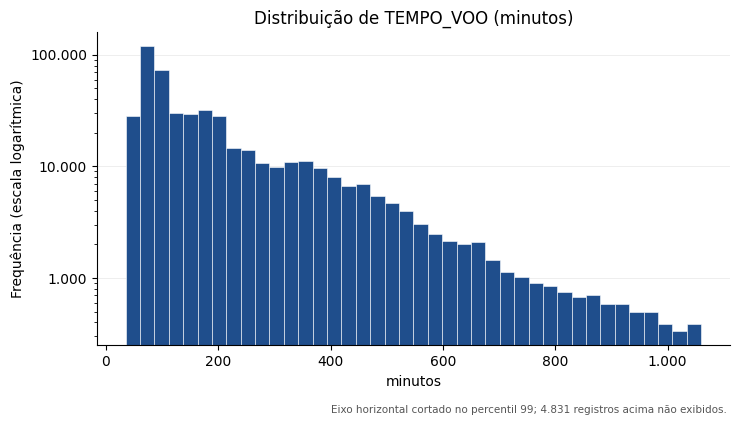

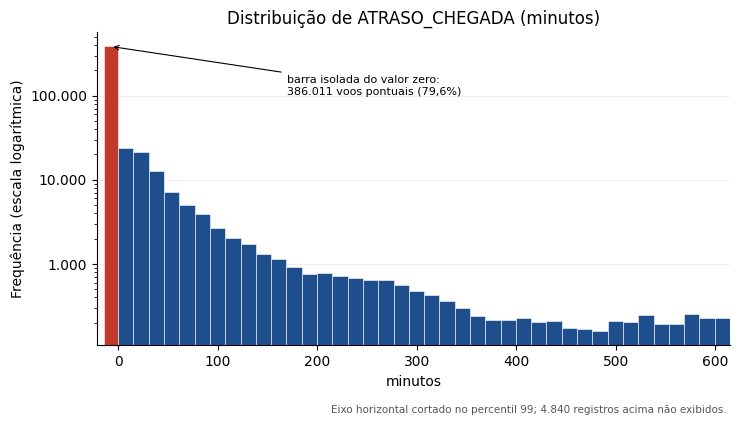

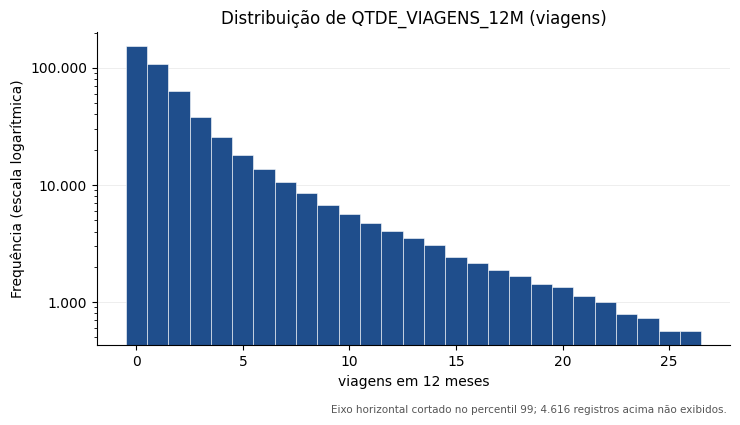

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

CAMINHOS_ASSETS = [Path('assets'), Path('../assets'), Path('/content/assets')]
caminho_assets = next((c for c in CAMINHOS_ASSETS if c.exists()), Path('assets'))


def formato_milhar(valor, _=None):
    # Separador de milhar com ponto, mesma norma usada no texto do documento.
    return f'{int(valor):,}'.replace(',', '.')


# titulo, rotulo do eixo x, isolar o valor zero, usar intervalos inteiros
ESPECIFICACOES = {
    'TEMPO_VOO': ('Distribuição de TEMPO_VOO (minutos)', 'minutos', False, False),
    'ATRASO_CHEGADA': ('Distribuição de ATRASO_CHEGADA (minutos)', 'minutos', True, False),
    'QTDE_VIAGENS_12M': ('Distribuição de QTDE_VIAGENS_12M (viagens)', 'viagens em 12 meses', False, True),
}

for coluna, (titulo, rotulo_x, isolar_zero, inteiros) in ESPECIFICACOES.items():
    serie = df[coluna].dropna()
    p99 = serie.quantile(0.99)
    acima_p99 = int((serie > p99).sum())

    if inteiros:
        # Variavel de contagem: um intervalo por valor inteiro, senao intervalos
        # fracionarios criam vaos vazios que nao existem nos dados.
        limites = np.arange(serie.min(), p99 + 2) - 0.5
    else:
        limites = np.linspace(0 if isolar_zero else serie.min(), p99, 41)
    largura = limites[1] - limites[0]

    fig, ax = plt.subplots(figsize=(7.5, 4.4))

    if isolar_zero:
        zeros = int((serie == 0).sum())
        ax.bar(-largura / 2, zeros, width=largura * 0.92,
               color='#c0392b', edgecolor='white', linewidth=0.4)
        ax.hist(serie[(serie > 0) & (serie <= p99)], bins=limites,
                edgecolor='white', linewidth=0.4, color='#1f4e8c')
        ax.set_xlim(-largura * 1.4, p99)
        # A virgula decimal vale so para o percentual: aplicar replace na frase
        # inteira trocaria tambem o separador de milhar de 386.011 para 386,011.
        percentual = f'{zeros / len(serie):.1%}'.replace('.', ',')
        ax.annotate(
            f'barra isolada do valor zero:\n{formato_milhar(zeros)} voos pontuais ({percentual})',
            xy=(-largura / 2, zeros), xytext=(0.30, 0.80), textcoords='axes fraction',
            fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8),
        )
    else:
        ax.hist(serie[serie <= p99], bins=limites,
                edgecolor='white', linewidth=0.4, color='#1f4e8c')

    ax.set_yscale('log')
    ax.set_title(titulo)
    ax.set_xlabel(rotulo_x)
    ax.set_ylabel('Frequência (escala logarítmica)')
    ax.yaxis.set_major_formatter(FuncFormatter(formato_milhar))
    ax.xaxis.set_major_formatter(FuncFormatter(formato_milhar))
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    ax.text(
        0.995, -0.19,
        f'Eixo horizontal cortado no percentil 99; {formato_milhar(acima_p99)} '
        'registros acima não exibidos.',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5, color='#555555',
    )

    fig.tight_layout()
    fig.savefig(caminho_assets / f'histograma_{coluna.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 1. Constantes do conjunto completo (seção A.1.3)

As constantes vêm do conjunto completo, e não de uma amostra ou de um recorte de treino. De cada
variável são excluídos apenas os registros sem valor para aquela variável, o que explica a coluna
`n_valido`. O desvio reportado é o **populacional** (divisor N), que é o usado na padronização; o
amostral aparece ao lado só para mostrar que a diferença é desprezível neste volume.

In [4]:
constantes = pd.DataFrame([
    {
        'variavel': coluna,
        'n_valido': int(df[coluna].notna().sum()),
        'nulos': int(df[coluna].isna().sum()),
        'minimo': df[coluna].min(),
        'maximo': df[coluna].max(),
        'media': round(df[coluna].mean(), 4),
        'desvio_populacional': round(df[coluna].std(ddof=0), 4),
        'desvio_amostral': round(df[coluna].std(ddof=1), 4),
    }
    for coluna in VARIAVEIS
]).set_index('variavel')

constantes

,n_valido,nulos,minimo,maximo,media,desvio_populacional,desvio_amostral
variavel,,,,,,,
TEMPO_VOO,484675,240,35.0,4320.0,207.1565,208.2920,208.2922
ATRASO_CHEGADA,484915,0,0.0,4319.0,25.6551,136.4553,136.4555
QTDE_VIAGENS_12M,484760,155,0.0,107.0,3.1690,5.4124,5.4124


## 2. Assimetria, percentil 95 e o teste do logaritmo (seções A.1.2 e A.1.4)

Origem dos dois números de assimetria citados no documento: o **3,68** de `TEMPO_VOO`, que aparece
no quadro da seção A.1.2, e o **0,69** obtido ao aplicar logaritmo nessa mesma variável, usado na
seção A.1.4 para dimensionar o que uma transformação de distribuição faria e a padronização não faz.

In [5]:
assimetria = pd.DataFrame(
    {
        'assimetria': [df[c].skew() for c in VARIAVEIS],
        'mediana': [df[c].median() for c in VARIAVEIS],
        'p95': [df[c].quantile(0.95) for c in VARIAVEIS],
        'razao_desvio_media': [df[c].std(ddof=0) / df[c].mean() for c in VARIAVEIS],
    },
    index=VARIAVEIS,
).round(4)

tempo_voo = df['TEMPO_VOO'].dropna()
print(f'assimetria de TEMPO_VOO ......... {tempo_voo.skew():.4f}')
print(f'assimetria de log(TEMPO_VOO) .... {np.log(tempo_voo).skew():.4f}')

assimetria

assimetria de TEMPO_VOO ......... 3.6829
assimetria de log(TEMPO_VOO) .... 0.6913


,assimetria,mediana,p95,razao_desvio_media
TEMPO_VOO,3.6829,130.0,575.0,1.0055
ATRASO_CHEGADA,10.7552,0.0,94.0,5.3188
QTDE_VIAGENS_12M,4.1238,1.0,13.0,1.7079


## 3. Constantes publicadas nas equações (seção A.1.4)

As equações do documento trazem as constantes arredondadas na quarta casa decimal. São elas, e não
as de precisão cheia, que ficam fixas no código: é o mesmo número que o leitor consegue substituir à
mão. A célula confere que o arredondamento não altera o resultado de forma perceptível.

In [6]:
MEDIA_TEMPO_VOO = 207.1565
DESVIO_TEMPO_VOO = 208.2920

MEDIA_ATRASO_CHEGADA = 25.6551
DESVIO_ATRASO_CHEGADA = 136.4553

MINIMO_QTDE_VIAGENS_12M = 0
MAXIMO_QTDE_VIAGENS_12M = 107

for coluna, media_publicada, desvio_publicado in [
    ('TEMPO_VOO', MEDIA_TEMPO_VOO, DESVIO_TEMPO_VOO),
    ('ATRASO_CHEGADA', MEDIA_ATRASO_CHEGADA, DESVIO_ATRASO_CHEGADA),
]:
    serie = df[coluna].dropna()
    com_precisao_cheia = (serie - serie.mean()) / serie.std(ddof=0)
    com_constante_publicada = (serie - media_publicada) / desvio_publicado
    diferenca = (com_precisao_cheia - com_constante_publicada).abs().max()
    print(f'{coluna}: diferença máxima entre as duas versões = {diferenca:.2e}')

TEMPO_VOO: diferença máxima entre as duas versões = 1.79e-06
ATRASO_CHEGADA: diferença máxima entre as duas versões = 1.08e-05


## 4. Aplicação da transformação

Cada variável recebe uma coluna escalonada nova e a coluna original permanece intacta.

**Registros sem valor.** A equação não é definida para ausência, então o nulo atravessa a
transformação e a coluna escalonada continua nula. Preencher com zero seria errado nos dois métodos:
na padronização o zero é a média da distribuição, e na normalização é o mínimo. A decisão sobre
imputar ou descartar esses registros pertence à preparação dos dados da seção 4.3, não ao
escalonamento.

In [7]:
ESCALONADAS = ['TEMPO_VOO_ESC', 'ATRASO_CHEGADA_ESC', 'QTDE_VIAGENS_12M_ESC']

df['TEMPO_VOO_ESC'] = (df['TEMPO_VOO'] - MEDIA_TEMPO_VOO) / DESVIO_TEMPO_VOO
df['ATRASO_CHEGADA_ESC'] = (df['ATRASO_CHEGADA'] - MEDIA_ATRASO_CHEGADA) / DESVIO_ATRASO_CHEGADA
df['QTDE_VIAGENS_12M_ESC'] = (
    (df['QTDE_VIAGENS_12M'] - MINIMO_QTDE_VIAGENS_12M)
    / (MAXIMO_QTDE_VIAGENS_12M - MINIMO_QTDE_VIAGENS_12M)
)

for original, escalonada in zip(VARIAVEIS, ESCALONADAS):
    print(
        f'{original:<18} {df[original].isna().sum():>4} nulos antes  |  '
        f'{df[escalonada].isna().sum():>4} nulos depois'
    )

TEMPO_VOO           240 nulos antes  |   240 nulos depois
ATRASO_CHEGADA        0 nulos antes  |     0 nulos depois
QTDE_VIAGENS_12M    155 nulos antes  |   155 nulos depois


## 5. Conferência manual entre a equação e a coluna gerada

A conferência usa três registros escolhidos por terem as três variáveis com valores não triviais.
Um registro em que a contagem de viagens ou o atraso valem zero não exercita a equação: `0 / 107`
devolve zero por construção e o atraso zero apenas testa o mínimo observado.

Cada registro é identificado pelo `RESPONDENT_ID`, chave de integração das quatro fontes e único na
base. Identificar por posição deixaria a tabela dependente da ordem em que `pre-processamento.ipynb`
concatena as fontes: uma mudança nessa ordem ou na regra de deduplicação invalidaria a conferência
sem que a comparação abaixo acusasse, já que ela confronta valores e não linhas. A seleção por chave
falha de forma explícita se o registro deixar de existir.

In [8]:
IDS_CONFERENCIA = [28211986, 28212172, 28213342]  # RESPONDENT_ID dos registros conferidos

selecao = df[df['RESPONDENT_ID'].isin(IDS_CONFERENCIA)]
assert len(selecao) == len(IDS_CONFERENCIA), 'RESPONDENT_ID da conferência não encontrado na base'

conferencia = selecao.set_index('RESPONDENT_ID').loc[IDS_CONFERENCIA, VARIAVEIS + ESCALONADAS].copy()

manual = pd.DataFrame({
    'TEMPO_VOO_ESC': (conferencia['TEMPO_VOO'] - 207.1565) / 208.2920,
    'ATRASO_CHEGADA_ESC': (conferencia['ATRASO_CHEGADA'] - 25.6551) / 136.4553,
    'QTDE_VIAGENS_12M_ESC': conferencia['QTDE_VIAGENS_12M'] / 107,
})

for coluna in ESCALONADAS:
    assert np.allclose(manual[coluna], conferencia[coluna]), coluna

print('A conferência manual reproduz a coluna gerada nos três registros.')

conferencia.round(4)

A conferência manual reproduz a coluna gerada nos três registros.


,TEMPO_VOO,ATRASO_CHEGADA,QTDE_VIAGENS_12M,TEMPO_VOO_ESC,ATRASO_CHEGADA_ESC,QTDE_VIAGENS_12M_ESC
RESPONDENT_ID,,,,,,
28211986,65.0,76,13.0,-0.6825,0.3689,0.1215
28212172,590.0,178,3.0,1.8380,1.1164,0.0280
28213342,140.0,11,45.0,-0.3224,-0.1074,0.4206


## 6. Valores fora do intervalo em dados futuros

As constantes são fixas, então um Cliente futuro com mais viagens que o máximo da base produz um
valor acima de 1. Nenhum truncamento é aplicado: cortar no teto faria Clientes diferentes receberem
o mesmo valor e quebraria a relação linear entre a variável e sua versão escalonada. O valor acima
de 1 é informação, e sinaliza que o teto observado na base foi ultrapassado.

Modelos que exijam entrada estritamente em [0, 1] precisam tratar isso na etapa de modelagem, e não
aqui.

In [9]:
futuros = pd.DataFrame({'QTDE_VIAGENS_12M': [0, 3, 13, 107, 120]})
futuros['QTDE_VIAGENS_12M_ESC'] = (
    (futuros['QTDE_VIAGENS_12M'] - MINIMO_QTDE_VIAGENS_12M)
    / (MAXIMO_QTDE_VIAGENS_12M - MINIMO_QTDE_VIAGENS_12M)
)

futuros.set_index('QTDE_VIAGENS_12M').round(4)

,QTDE_VIAGENS_12M_ESC
QTDE_VIAGENS_12M,
0,0.0000
3,0.0280
13,0.1215
107,1.0000
120,1.1215


## 7. Amplitude das três colunas escalonadas

As duas colunas padronizadas e a normalizada chegam ao modelo em faixas bem diferentes. A tabela
abaixo é a evidência quantitativa da ressalva registrada no fim da seção A.1.4.

Esta seção também reúne os números que a seção A.1.4 usa para dimensionar a compressão de
`QTDE_VIAGENS_12M`: a média da coluna escalonada, a fatia da base que cabe nos primeiros 3% do
intervalo e a distância, em desvios padrão, entre o máximo e a média da variável original.

In [10]:
amplitude = pd.DataFrame(
    {
        'minimo': [df[c].min() for c in ESCALONADAS],
        'maximo': [df[c].max() for c in ESCALONADAS],
        'media': [df[c].mean() for c in ESCALONADAS],
        'desvio_populacional': [df[c].std(ddof=0) for c in ESCALONADAS],
    },
    index=ESCALONADAS,
).round(4)

frequencia = df['QTDE_VIAGENS_12M_ESC'].dropna()
print(f'QTDE_VIAGENS_12M_ESC: {(frequencia <= 0.03).mean() * 100:.1f}% dos registros ficam em 0,03 ou abaixo')

frequencia_original = df['QTDE_VIAGENS_12M'].dropna()
distancia_do_maximo = (
    (frequencia_original.max() - frequencia_original.mean()) / frequencia_original.std(ddof=0)
)
print(
    f'QTDE_VIAGENS_12M: o máximo de {frequencia_original.max():.0f} viagens está a '
    f'{distancia_do_maximo:.2f} desvios padrão da média de {frequencia_original.mean():.4f}'
)

amplitude

QTDE_VIAGENS_12M_ESC: 74.3% dos registros ficam em 0,03 ou abaixo


QTDE_VIAGENS_12M: o máximo de 107 viagens está a 19.18 desvios padrão da média de 3.1690


,minimo,maximo,media,desvio_populacional
TEMPO_VOO_ESC,-0.8265,19.7456,-0.0000,1.0000
ATRASO_CHEGADA_ESC,-0.1880,31.4634,0.0000,1.0000
QTDE_VIAGENS_12M_ESC,0.0000,1.0000,0.0296,0.0506
